# code_lec-02
# Imbalanced dataset

# class imbalne >> when the difference in percentage of both the classs is huge

# how to handle ?

1. upsampling  (oversampling )
2. downsampling (undersampling )
3. SMOTE (synthetic minority oversampling techniques)

In [1]:
import pandas as pd
import numpy as np

np.random.seed(1) # for reproducibility of result

no_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(no_samples * class_0_ratio)
n_class_1 = no_samples - n_class_0

In [2]:
n_class_0,n_class_1

(900, 100)

In [3]:
class_0 = pd.DataFrame({'feature1': np.random.normal( 0,1 , n_class_0), # np.random.normal(mean, std_dev, no.of.samples)    
          'feature2':np.random.normal(0,1, n_class_0),
           'target': [0]*n_class_0})

In [4]:
class_0


,feature1,feature2,target
0,1.624345,-0.446699,0
1,-0.611756,0.204377,0
2,-0.528172,0.612233,0
3,-1.072969,0.744885,0
4,0.865408,-0.036281,0
...,...,...,...
895,0.578464,0.833679,0
896,-0.961264,2.160456,0
897,-1.458324,1.998992,0
898,0.494342,0.764041,0


In [5]:
class_1 =pd.DataFrame({'feature1': np.random.normal( 3,1 , n_class_1),
          'feature2':np.random.normal(3,1, n_class_1),
           'target': [1]*n_class_1})

In [6]:
class_1

,feature1,feature2,target
0,1.692029,3.933630,1
1,4.472396,1.236225,1
2,3.074876,2.589783,1
3,1.213065,2.546333,1
4,3.165211,2.410570,1
...,...,...,...
95,3.213026,3.188583,1
96,2.195458,3.560918,1
97,2.353418,2.078341,1
98,4.138173,3.647375,1


In [7]:
df = pd.concat([class_0,class_1]).reset_index(drop=True)
df

,feature1,feature2,target
0,1.624345,-0.446699,0
1,-0.611756,0.204377,0
2,-0.528172,0.612233,0
3,-1.072969,0.744885,0
4,0.865408,-0.036281,0
...,...,...,...
995,3.213026,3.188583,1
996,2.195458,3.560918,1
997,2.353418,2.078341,1
998,4.138173,3.647375,1


In [8]:
df.target.value_counts()

target
0    900
1    100
Name: count, dtype: int64

# upsampling

In [9]:
df_minority = df[df.target == 1 ]
df_majority = df[df.target == 0 ]

In [10]:
df_minority

,feature1,feature2,target
900,1.692029,3.933630,1
901,4.472396,1.236225,1
902,3.074876,2.589783,1
903,1.213065,2.546333,1
904,3.165211,2.410570,1
...,...,...,...
995,3.213026,3.188583,1
996,2.195458,3.560918,1
997,2.353418,2.078341,1
998,4.138173,3.647375,1


In [11]:
df_majority

,feature1,feature2,target
0,1.624345,-0.446699,0
1,-0.611756,0.204377,0
2,-0.528172,0.612233,0
3,-1.072969,0.744885,0
4,0.865408,-0.036281,0
...,...,...,...
895,0.578464,0.833679,0
896,-0.961264,2.160456,0
897,-1.458324,1.998992,0
898,0.494342,0.764041,0


In [12]:
# replace >> if replace  is true , it means data point caan be repeated

from sklearn.utils import resample
df_minority_upsampled = resample(df_minority , replace = True , n_samples = len(df_majority) , random_state= 1)

In [13]:
df_minority_upsampled

,feature1,feature2,target
937,2.253776,1.681477,1
912,2.448320,2.898619,1
972,2.541698,2.700847,1
909,1.724886,1.748043,1
975,2.427974,4.613562,1
...,...,...,...
936,4.093307,2.373543,1
998,4.138173,3.647375,1
901,4.472396,1.236225,1
932,1.965537,4.084419,1


In [14]:
df_minority_upsampled.shape

(900, 3)

In [15]:
# concat

df_upsampled = pd.concat([df_majority , df_minority_upsampled]).reset_index(drop=True)
df_upsampled

,feature1,feature2,target
0,1.624345,-0.446699,0
1,-0.611756,0.204377,0
2,-0.528172,0.612233,0
3,-1.072969,0.744885,0
4,0.865408,-0.036281,0
...,...,...,...
1795,4.093307,2.373543,1
1796,4.138173,3.647375,1
1797,4.472396,1.236225,1
1798,1.965537,4.084419,1


In [16]:
df_upsampled.target.value_counts()

target
0    900
1    900
Name: count, dtype: int64

# Downsampling

In [17]:
df_minority

,feature1,feature2,target
900,1.692029,3.933630,1
901,4.472396,1.236225,1
902,3.074876,2.589783,1
903,1.213065,2.546333,1
904,3.165211,2.410570,1
...,...,...,...
995,3.213026,3.188583,1
996,2.195458,3.560918,1
997,2.353418,2.078341,1
998,4.138173,3.647375,1


In [18]:
# Majority should be decreased to minority

df_majority_downsampled = resample(df_majority , replace = False , n_samples = len(df_minority) , random_state= 1)

In [19]:
df_majority_downsampled

,feature1,feature2,target
860,-0.977773,0.872579,0
880,0.309817,1.835870,0
874,0.050317,0.146532,0
780,0.677808,-0.859827,0
525,0.713049,0.320971,0
...,...,...,...
494,-1.579156,2.711950,0
255,-1.044589,0.522655,0
672,0.410266,0.683356,0
481,-1.114871,-0.800787,0


In [20]:
df_downsampled = pd.concat([df_minority , df_majority_downsampled]).reset_index(drop=True)

In [21]:
df_downsampled

,feature1,feature2,target
0,1.692029,3.933630,1
1,4.472396,1.236225,1
2,3.074876,2.589783,1
3,1.213065,2.546333,1
4,3.165211,2.410570,1
...,...,...,...
195,-1.579156,2.711950,0
196,-1.044589,0.522655,0
197,0.410266,0.683356,0
198,-1.114871,-0.800787,0


In [22]:
df_downsampled.target.value_counts()

target
1    100
0    100
Name: count, dtype: int64

# SMOTE

In [23]:
from sklearn.datasets import make_classification

x,y = make_classification(n_samples = 1000, n_redundant = 0 , n_features = 2 , n_clusters_per_class = 1 , weights=[0.90]) 

# n_redundant >> gives no. of redundant features
# n_features >> gives no. of features
# n_clusters_per_class >> gives no. of clusters per class
# weights >> gives the imbalance ratio


In [24]:
x

array([[-1.07876139,  0.6322917 ],
       [-1.62310799, -0.05386502],
       [-0.92187944,  1.34630462],
       ...,
       [-2.22214902, -1.74577853],
       [-0.9482506 ,  1.25173138],
       [-1.19836117,  1.37319785]], shape=(1000, 2))

In [25]:
y

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [26]:
df1 = pd.DataFrame(x, columns = ['feature1','feature2'])
df2 = pd.DataFrame(y,columns = ['target'])
final_df = pd.concat([df1,df2], axis = 1)


In [27]:
final_df

,feature1,feature2,target
0,-1.078761,0.632292,0
1,-1.623108,-0.053865,0
2,-0.921879,1.346305,0
3,-2.014224,0.242973,0
4,0.707407,0.382432,1
...,...,...,...
995,-1.617138,0.720443,0
996,-0.674183,1.593318,0
997,-2.222149,-1.745779,1
998,-0.948251,1.251731,0


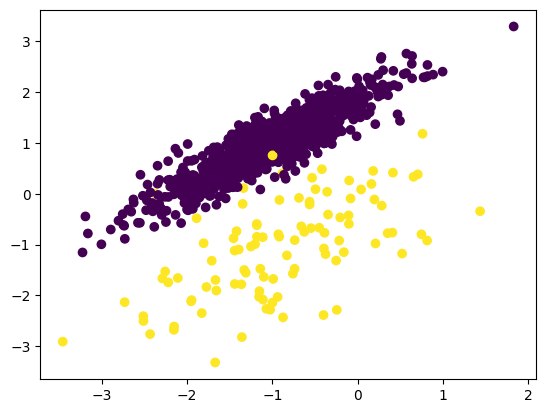

In [28]:
import matplotlib.pyplot as plt
plt.scatter(final_df['feature1'] , final_df['feature2'] , c = final_df['target'])
plt.show()

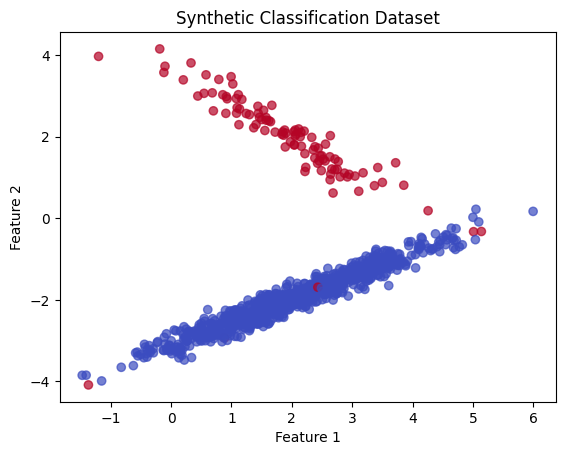

In [29]:
# chatgpt

from sklearn.datasets import make_classification
import pandas as pd
import matplotlib.pyplot as plt

# Generate dataset
x, y = make_classification(
    n_samples=1000,
    n_features=2,       # only 2 features for 2D scatter
    n_redundant=0,      # redundant means not useful features
    n_informative=2,    # make both features informative
    n_clusters_per_class=1, # it means one cluster for each class
    weights=[0.90],     # imbalanced classes
    class_sep=2.0,      # increase class separation
    random_state=42
)

# Put into dataframe
df1 = pd.DataFrame(x, columns=['feature1','feature2'])
df2 = pd.DataFrame(y, columns=['target'])
final_df = pd.concat([df1, df2], axis=1)

# Plot
plt.scatter(final_df['feature1'], final_df['feature2'], c=final_df['target'], cmap='coolwarm', alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Classification Dataset")
plt.show()



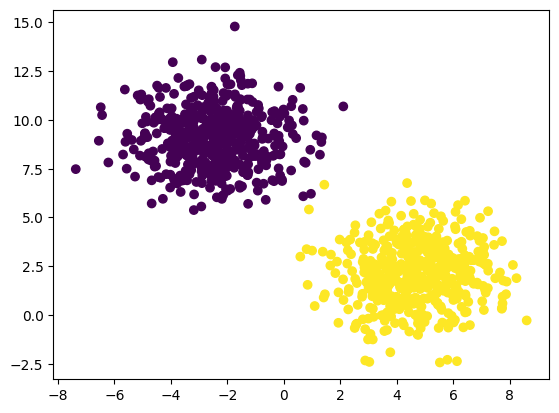

In [30]:
# using make_blobs chatgpt

from sklearn.datasets import make_blobs
import pandas as pd
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=1000, centers=2, cluster_std=1.5, random_state=42)

df1 = pd.DataFrame(X, columns=['feature1','feature2'])
df2 = pd.DataFrame(y, columns=['target'])
final_df = pd.concat([df1,df2], axis=1)

plt.scatter(final_df['feature1'], final_df['feature2'], c=final_df['target'])
plt.show()


In [33]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE()
x,y = oversample.fit_resample(final_df[['feature1','feature2']] , final_df['target'])

In [ ]:
x.shape

(1000, 2)

In [ ]:
y.shape

(1000,)

In [ ]:
df1 = pd.DataFrame(x, columns = ['feature1','feature2'])
df2 = pd.DataFrame(y,columns = ['target'])
smote_df = pd.concat([df1,df2], axis = 1)


In [ ]:
smote_df

,feature1,feature2,target
0,-1.255659,7.319726,0
1,7.156430,1.142787,1
2,2.995466,-0.186907,1
3,5.424132,1.112620,1
4,4.369159,6.762831,1
...,...,...,...
995,-1.560025,12.420325,0
996,5.727523,2.747437,1
997,2.582027,-0.447172,1
998,6.328954,1.896079,1


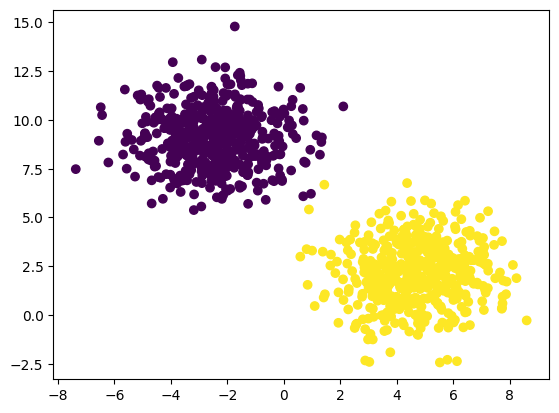

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(smote_df['feature1'] , smote_df['feature2'] , c = final_df['target'])
plt.show()